In [22]:
import xarray as xr 
import json
import numpy as np
import cmaps
import matplotlib.pyplot as plt
import pyicon as pyic
import subprocess
from pathlib import Path
import os

# Cartopy for geographic plotting
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmap
# import xesmf as xe
import glob

from slurm_cluster import init_dask_slurm_cluster
client, cluster = init_dask_slurm_cluster(scale=4, processes=16, cores=128, memory="256GiB", walltime="02:00:00")

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40187 instead
  warnings.warn(


#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /scratch/m/m301254/dask_log//dask-worker-%J.err
#SBATCH -o /scratch/m/m301254/dask_log//dask-worker-%J.out
#SBATCH -p compute
#SBATCH -A bm1102
#SBATCH -n 1
#SBATCH --cpus-per-task=128
#SBATCH --mem=256G
#SBATCH -t 02:00:00

/home/m/m301254/.conda/envs/env02_waves/bin/python -m distributed.cli.dask_worker tcp://10.128.1.79:41103 --name dummy-name --nthreads 8 --memory-limit 16.00GiB --nworkers 16 --nanny --death-timeout 60 --local-directory /scratch/m/m301254/dask_tmp/ --interface ib0



Task exception was never retrieved
future: <Task finished name='Task-1265702' coro=<Client._gather.<locals>.wait() done, defined at /home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:2384> exception=AllExit()>
Traceback (most recent call last):
  File "/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py", line 2393, in wait
    raise AllExit()
distributed.client.AllExit


explain the imported function: init_dask_slurm_cluster
- **scale**: number of SLURM jobs submitted to the cluster. each job typically runs one compute node; scale=2 -> 2 nodes requested
- **processes**: Number of independent Dask worker processes launched per node. Each process handles a separate chunk of work in parallel. Total workers = scale * processes = 2 * 20 = 40
- **cores**: Total CPU cores allocated per node (i.e., per SLURM job). These are divided among the processes:
    - Threads per worker = cores / processes = 100 / 20 = 5 threads per worker
    - Each worker is multi-threaded (useful for numpy/xarray which release the GIL)
- **memory**: Total RAM requested per node from SLURM. Divided among the workers: RAM per worker = 200 GiB / 20 = 10 GiB per worker
- **walltime**: Maximum time each SLURM job is allowed to run (HH:MM:SS). After 10 minutes, SLURM will kill the job regardless of completion status.


# Compare surface stokes drift velocity from **ICON-wave standalone** output to the **ERA5 wave output** 
- compare the monthly mean surface stokes drift velocity in both directions (U- and V-component) in the year of 2024
- Data directory:
    - ICON-wave standalone: `/work/uo1075/u241211/icon-waves_era5/icon-nwp/build/experiments/run_ICON_18_R2B7_waves_standalone_era5/`
    - ERA5 ecWAM: `/work/mh0033/m301254/proj_surfwave/processed_data/era5/`
- A clearer overview of the differences between ERA5 and ICON-Waves can be achieved by co-locating each grid cell geographically and in time without grid interpolation and presenting the results in a scatter plot, and/or in correlation/RMSE maps.

In [23]:
# read data
# ICON-wave
icon_dir = "/work/uo1075/u241211/icon-waves_era5/icon-nwp/build/experiments/run_ICON_18_R2B7_waves_standalone_era5/"
icon_ds = xr.open_dataset(f"{icon_dir}wave_Stokes_DOM01_ML_0001_2024.nc", chunks={"time": 24},)[["u_stokes", "v_stokes"]] 
# convert radians to degrees for easier plotting
icon_ds = icon_ds.assign_coords(
    clon=np.rad2deg(icon_ds.clon),
    clat=np.rad2deg(icon_ds.clat),
)

# ERA5 ECWAM
era5_dir = "/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/"
era5_ds = xr.open_dataset(f"{era5_dir}era5_Stokes_2024.grib",engine="cfgrib", chunks={"time": 24})

print("=== ICON ===")
print(icon_ds)
print("\n=== ERA5 ===")
print(era5_ds)

=== ICON ===
<xarray.Dataset> Size: 64GB
Dimensions:   (time: 8784, ncells: 917227)
Coordinates:
  * time      (time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-31T23:00:00
    clon      (ncells) float64 7MB dask.array<chunksize=(917227,), meta=np.ndarray>
    clat      (ncells) float64 7MB dask.array<chunksize=(917227,), meta=np.ndarray>
Dimensions without coordinates: ncells
Data variables:
    u_stokes  (time, ncells) float32 32GB dask.array<chunksize=(24, 917227), meta=np.ndarray>
    v_stokes  (time, ncells) float32 32GB dask.array<chunksize=(24, 917227), meta=np.ndarray>
Attributes:
    CDI:                       Climate Data Interface version 2.2.4 (https://...
    Conventions:               CF-1.6
    uuidOfHGrid:               0a278995-c61b-2e35-e273-fa3666cd2b40
    source:                    version: 2025.10; revision: icon-2025.04-dwd-4...
    institution:               Max Planck Institute for Meteorology/Deutscher...
    title:                     ICON simulation
    hist

## Temporal averaging to avoid large dataset

In [24]:
# monthly mean
icon_mon = icon_ds.resample(time="1M").mean()
era5_mon = era5_ds.resample(time="1M").mean()

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/xarray/groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/xarray/groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


## Co-locate ERA5 to ICON unstructured grid (nearest neighbour, no interpolation)

### build nearest-neighbour mapping

In [25]:
from scipy.spatial import cKDTree
# ERA5 grid
lon2d, lat2d = np.meshgrid(era5_ds.longitude, era5_ds.latitude)

era_points = np.column_stack([
    lat2d.ravel(),
    lon2d.ravel()
])

tree = cKDTree(era_points)

# ICON grid
icon_points = np.column_stack([
    icon_ds.clat.values,
    icon_ds.clon.values
])

dist, idx = tree.query(icon_points)

### Attach ERA5 data to ICON grid

In [26]:
era5_u_flat = era5_mon.ust.stack(point=("latitude","longitude"))
era5_v_flat = era5_mon.vst.stack(point=("latitude","longitude"))

In [27]:
era5_u_on_icon = era5_u_flat.isel(point=xr.DataArray(idx, dims="ncells"))
era5_v_on_icon = era5_v_flat.isel(point=xr.DataArray(idx, dims="ncells"))

### Co-located dataset

In [54]:
icon_u = icon_mon.u_stokes
icon_v = icon_mon.v_stokes

era5_u = era5_u_on_icon
era5_v = era5_v_on_icon

## Scatter plot: 

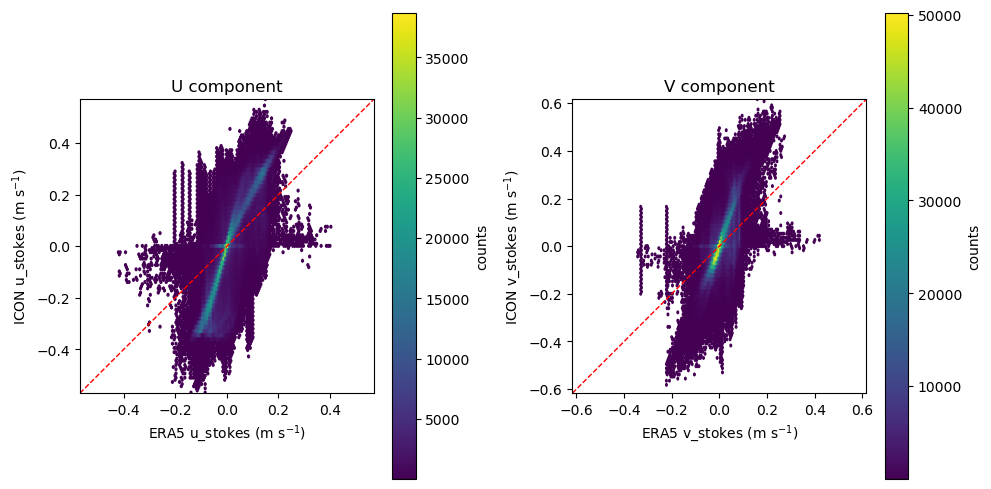

In [55]:
step = 1
cells = np.arange(0, icon_u.sizes["ncells"], step)

# flatten arrays
x_u = era5_u.isel(ncells=cells).values.flatten()
y_u = icon_u.isel(ncells=cells).values.flatten()

x_v = era5_v.isel(ncells=cells).values.flatten()
y_v = icon_v.isel(ncells=cells).values.flatten()

# remove NaNs
mask_u = np.isfinite(x_u) & np.isfinite(y_u)
x_u = x_u[mask_u]
y_u = y_u[mask_u]

mask_v = np.isfinite(x_v) & np.isfinite(y_v)
x_v = x_v[mask_v]
y_v = y_v[mask_v]

fig, axs = plt.subplots(1, 2, figsize=(10,5))

# -----------------------
# U component
# -----------------------
ax = axs[0]
hb = ax.hexbin(x_u, y_u, gridsize=120, mincnt=1)
m = max(np.nanmax(np.abs(x_u)), np.nanmax(np.abs(y_u)))
ax.plot([-m,m],[-m,m],'r--',linewidth=1)
ax.set_xlim(-m,m)
ax.set_ylim(-m,m)
ax.set_aspect("equal")
ax.set_xlabel("ERA5 u_stokes (m s$^{-1}$)")
ax.set_ylabel("ICON u_stokes (m s$^{-1}$)")
ax.set_title("U component")
fig.colorbar(hb, ax=ax, label="counts")

# -----------------------
# V component
# -----------------------
ax = axs[1]
hb = ax.hexbin(x_v, y_v, gridsize=120, mincnt=1)
m = max(np.nanmax(np.abs(x_v)), np.nanmax(np.abs(y_v)))
ax.plot([-m,m],[-m,m],'r--',linewidth=1)
ax.set_xlim(-m,m)
ax.set_ylim(-m,m)
ax.set_aspect("equal")
ax.set_xlabel("ERA5 v_stokes (m s$^{-1}$)")
ax.set_ylabel("ICON v_stokes (m s$^{-1}$)")
ax.set_title("V component")
fig.colorbar(hb, ax=ax, label="counts")

plt.tight_layout()
save_path = "/home/m/m301254/project_surfwaves/figs/icon-wave_testrun/icon_vs_era5_surfStokes_monthlymean_hexbin.png"
plt.savefig(save_path, dpi=150)
plt.show()

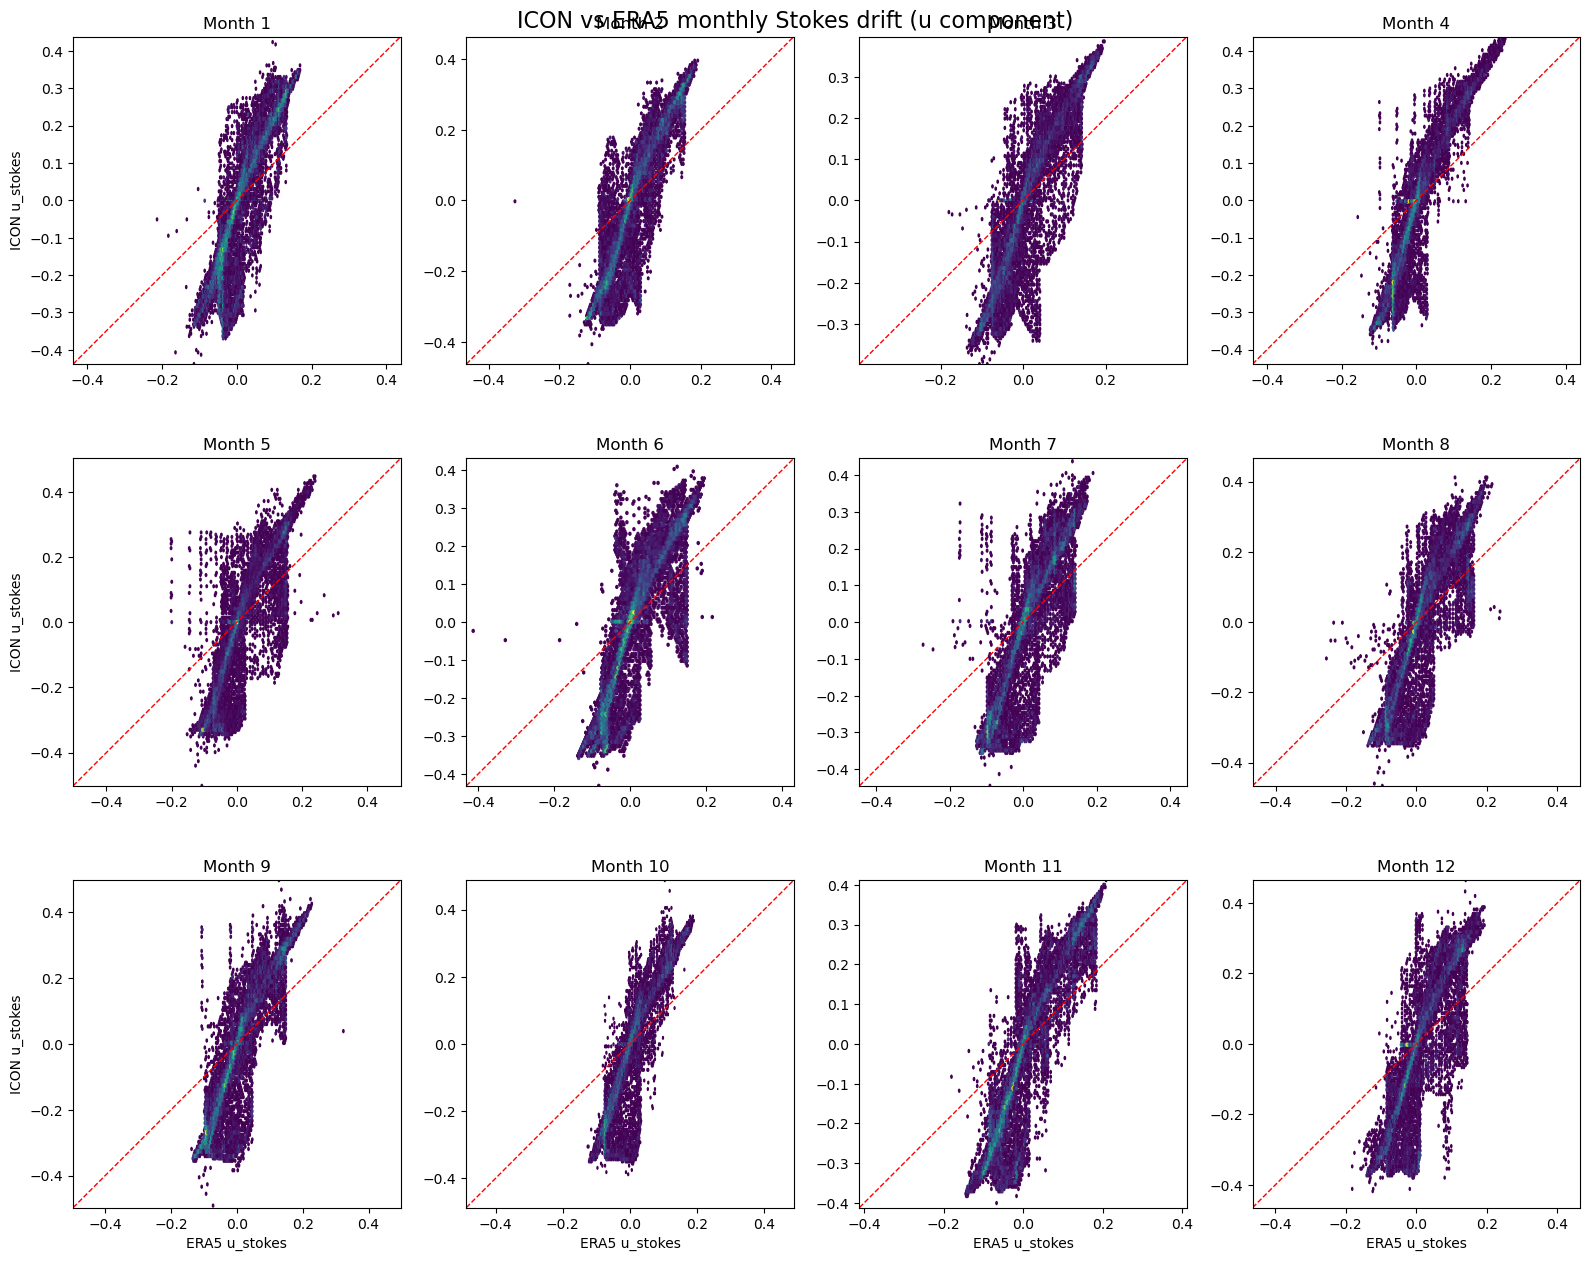

In [33]:
step = 50
cells = np.arange(0, icon_u.sizes["ncells"], step)
months = icon_u["time.month"]

fig, axs = plt.subplots(3,4, figsize=(16,13))
for m in range(1,13):
    ax = axs.flat[m-1]
    # select month
    icon_m = icon_u.where(months==m, drop=True)
    era5_m = era5_u.where(months==m, drop=True)
    # flatten
    x = era5_m.isel(ncells=cells).values.flatten()
    y = icon_m.isel(ncells=cells).values.flatten()
    # remove NaNs
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    hb = ax.hexbin(x, y, gridsize=120, mincnt=1)
    # axis limits
    mlim = max(np.nanmax(np.abs(x)), np.nanmax(np.abs(y)))
    ax.plot([-mlim,mlim],[-mlim,mlim],'r--',linewidth=1)
    ax.set_xlim(-mlim,mlim)
    ax.set_ylim(-mlim,mlim)
    ax.set_aspect("equal")
    ax.set_title(f"Month {m}")
    if m in [9,10,11,12]:
        ax.set_xlabel("ERA5 u_stokes")
    if m in [1,5,9]:
        ax.set_ylabel("ICON u_stokes")

plt.tight_layout()
# fig.colorbar(hb, ax=axs[2,:], orientation="horizontal", label="counts", pad=0.05, fraction=0.05)
plt.suptitle("ICON vs ERA5 monthly Stokes drift (u component)", fontsize=16)
save_path = "/home/m/m301254/project_surfwaves/figs/icon-wave_testrun/icon_vs_era5_surfStokes_u_monthly_hexbin.png"
plt.savefig(save_path, dpi=150)
plt.show()

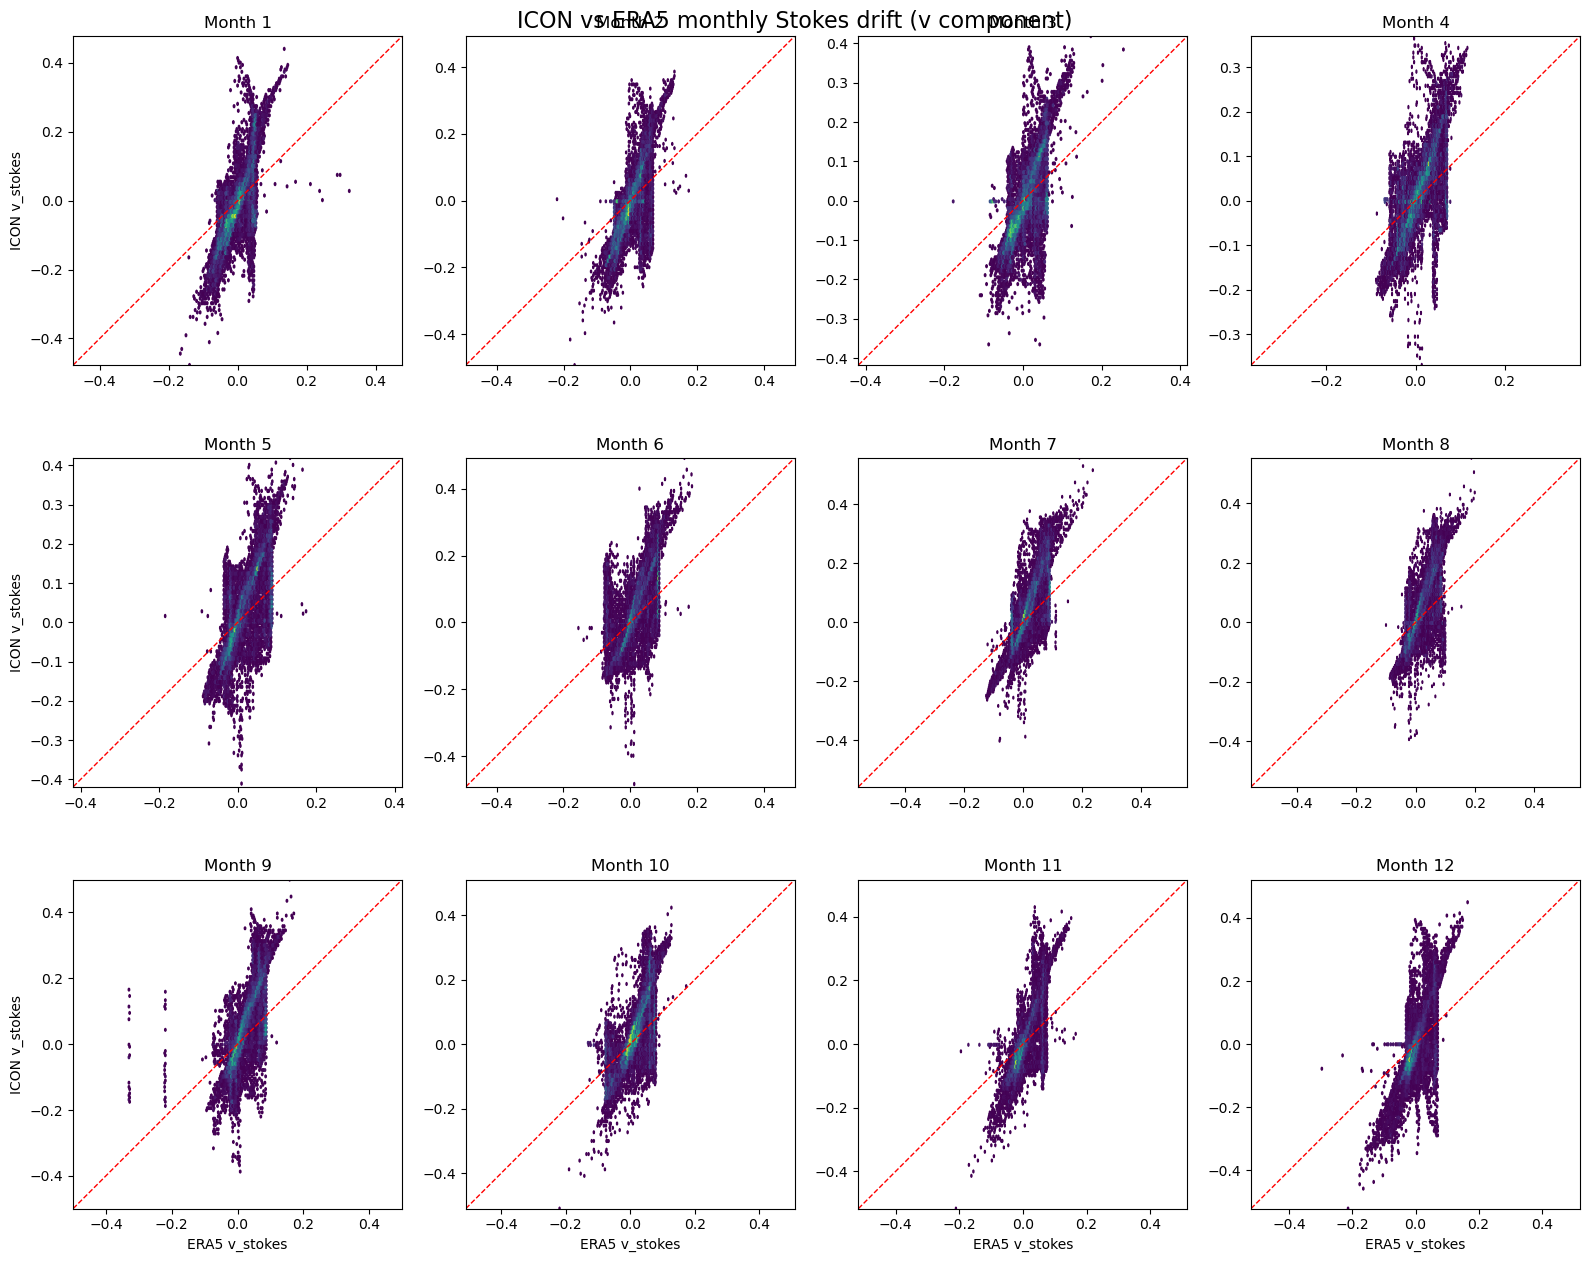

In [56]:
step = 50
cells = np.arange(0, icon_v.sizes["ncells"], step)
months = icon_v["time.month"]

fig, axs = plt.subplots(3,4, figsize=(16,13))
for m in range(1,13):
    ax = axs.flat[m-1]
    # select month
    icon_m = icon_v.where(months==m, drop=True)
    era5_m = era5_v.where(months==m, drop=True)
    # flatten
    x = era5_m.isel(ncells=cells).values.flatten()
    y = icon_m.isel(ncells=cells).values.flatten()
    # remove NaNs
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    hb = ax.hexbin(x, y, gridsize=120, mincnt=1)
    # axis limits
    mlim = max(np.nanmax(np.abs(x)), np.nanmax(np.abs(y)))
    ax.plot([-mlim,mlim],[-mlim,mlim],'r--',linewidth=1)
    ax.set_xlim(-mlim,mlim)
    ax.set_ylim(-mlim,mlim)
    ax.set_aspect("equal")
    ax.set_title(f"Month {m}")
    if m in [9,10,11,12]:
        ax.set_xlabel("ERA5 v_stokes")
    if m in [1,5,9]:
        ax.set_ylabel("ICON v_stokes")

plt.tight_layout()
# fig.colorbar(hb, ax=axs[2,:], orientation="horizontal", label="counts", pad=0.05, fraction=0.05)
plt.suptitle("ICON vs ERA5 monthly Stokes drift (v component)", fontsize=16)
save_path = "/home/m/m301254/project_surfwaves/figs/icon-wave_testrun/icon_vs_era5_surfStokes_v_monthly_hexbin.png"
plt.savefig(save_path, dpi=150)
plt.show()

## RMSE global map

In [57]:
step = 1
cells = np.arange(0, icon_u.sizes["ncells"], step)
months = np.arange(1,13)

monthly_rmse_u = []
monthly_rmse_v = []

for m in months:
    # select month
    icon_m = icon_u.where(icon_u['time.month']==m, drop=True).isel(ncells=cells)
    era5_m = era5_u_on_icon.where(era5_u_on_icon['time.month']==m, drop=True).isel(ncells=cells)
    
    diff_u = icon_m - era5_m
    rmse_u = np.sqrt((diff_u**2).mean(dim="time"))
    
    # drop time coord to avoid NetCDF issues
    rmse_u = rmse_u.drop_vars([v for v in rmse_u.coords if v != 'ncells'])
    
    icon_m_v = icon_v.where(icon_v['time.month']==m, drop=True).isel(ncells=cells)
    era5_m_v = era5_v_on_icon.where(era5_v_on_icon['time.month']==m, drop=True).isel(ncells=cells)
    
    diff_v = icon_m_v - era5_m_v
    rmse_v = np.sqrt((diff_v**2).mean(dim="time"))
    
    rmse_v = rmse_v.drop_vars([v for v in rmse_v.coords if v != 'ncells'])
    
    monthly_rmse_u.append(rmse_u)
    monthly_rmse_v.append(rmse_v)

# concatenate into a single DataArray
da_u = xr.concat(monthly_rmse_u, dim="month").assign_coords(month=months)
da_v = xr.concat(monthly_rmse_v, dim="month").assign_coords(month=months)

# save to NetCDF
da_u.to_netcdf("/work/mh0033/m301254/proj_surfwave/processed_data/icon-wave_testrun/icon_vs_era5_stokes_u_monthly_RMSE.nc")
da_v.to_netcdf("/work/mh0033/m301254/proj_surfwave/processed_data/icon-wave_testrun/icon_vs_era5_stokes_v_monthly_RMSE.nc")